# Network Analysis
To evaluate the systemic vulnerability of Hat Yai’s transportation infrastructure, this study employs graph theory to characterize the topological structure of the road network. Rather than treating all road segments as equal, intersections that act as essential bridges for city-wide connectivity and logistics are identified.

## Metric: Betweenness Centrality ($C_B$)
The primary metric utilized is **Betweenness Centrality**. In the context of urban resilience, this metric serves as a proxy for "topological stress," quantifying the extent to which a node lies on the shortest paths between other node pairs in the network.

<div style="display: flex; align-items: flex-start; gap: 25px; margin-top: 15px; margin-bottom: 20px;">

  <div style="flex: 0 0 65%;">
    <ul style="margin-top: 0; padding-left: 20px; margin-bottom: 15px;">
      <li style="margin-bottom: 10px;">
        <strong>High Centrality (Bright Colors):</strong> Nodes with high values form the structural backbone of the city. They represent the most efficient "bridge" routes essential for large-scale mobility (as shown by the central orange node in the figure).
      </li>
      <li>
        <strong>Low Centrality (Dark Colors):</strong> These are peripheral roads that play a minor role in overall city-wide connectivity. Their failure typically has limited impact on the core network.
      </li>
    </ul>
    <p style="margin-top: 0;">
      <strong>Systemic Impact of Failure:</strong> Crucially, the failure of critical high-centrality nodes does not merely result in localized disruption， it leads to systemic fragmentation. Traffic is forcibly redirected onto inefficient, peripheral detours, exponentially increasing travel times throughout the entire network.
    </p>
  </div>

  <div style="flex: 1;">
    <img src="data/betweenness.png" style="width: 100%; border-radius: 4px; border: 1px solid #eee; box-shadow: 0 2px 5px rgba(0,0,0,0.05);" alt="Conceptual Model of Betweenness Centrality">
    <p style="font-size: 0.85em; color: #666; margin-top: 8px; line-height: 1.3;">
      <em><strong>Betweenness Centrality Conceptual Model.</strong> The central node (bright yellow-orange) acts as the critical bridge connecting peripheral clusters.</em>
    </p>
  </div>

</div>

## Topological Stress Redistribution
The comparative visualization reveals a critical transformation in the topological structure of Hat Yai’s transport network under flood conditions. In the baseline scenario without flooding, the network exhibits a highly centralized structure. High betweenness centrality nodes, visualized in bright orange and yellow, align with the primary north-south and east-west arteries to facilitate efficient city-wide connectivity. However, the post-flood scenario demonstrates a systemic failure of this core infrastructure. The inundation of the city center effectively neutralizes critical "bridge" nodes and forces traffic flow toward the peripheral network, specifically shifting the load to the non-flooded routes in the northeast quadrant. Critically, this disruption extends beyond mere diversion. The extensive severance of road links has triggered a widespread systemic paralysis. Floodwaters have made the city fragmented and transformed previously connected neighborhoods into isolated "functional islands," effectively cutting off access for the vast majority of the network.


In [1]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

flood_path = "data/EOS-RS_20251109_FPM_S1_Philippines_Bicol_Region_Typhoon_Fung-Wong_v0.9_shp/EOS-RS_20251123_FPM_S1_Thailand_Hat_Yai_Floods_v0.9_shp.shp"

try:
    # Load flood extent
    flood_gdf = gpd.read_file(flood_path)
    
    # Load and project street network (Hat Yai)
    place_name = "Hat Yai, Songkhla, Thailand"
    G = ox.graph_from_place(place_name, network_type='drive') 
    G_proj = ox.project_graph(G)
    
    # Align CRS (Coordinate Reference Systems)
    graph_crs = G_proj.graph['crs']
    flood_utm = flood_gdf.to_crs(graph_crs)
    hat_yai_city = ox.geocode_to_gdf(place_name).to_crs(graph_crs)
    
    # Clip flood data to city boundary
    flood_clean = gpd.clip(flood_utm, hat_yai_city)
    
except Exception as e:
    print(f"❌ Data Error: {e}")

# pre-flood baseline
bc = nx.betweenness_centrality(ox.get_digraph(G_proj), weight='length')
nx.set_node_attributes(G_proj, bc, 'bc')

# post flood
nodes, edges = ox.graph_to_gdfs(G_proj)
flooded_nodes = gpd.sjoin(nodes, flood_clean, how='inner', predicate='intersects')
flooded_ids = flooded_nodes.index.tolist()

G_flood = G_proj.copy()
G_flood.remove_nodes_from(flooded_ids)

bc_flood = nx.betweenness_centrality(ox.get_digraph(G_flood), weight='length')
nx.set_node_attributes(G_flood, bc_flood, 'bc_flood')



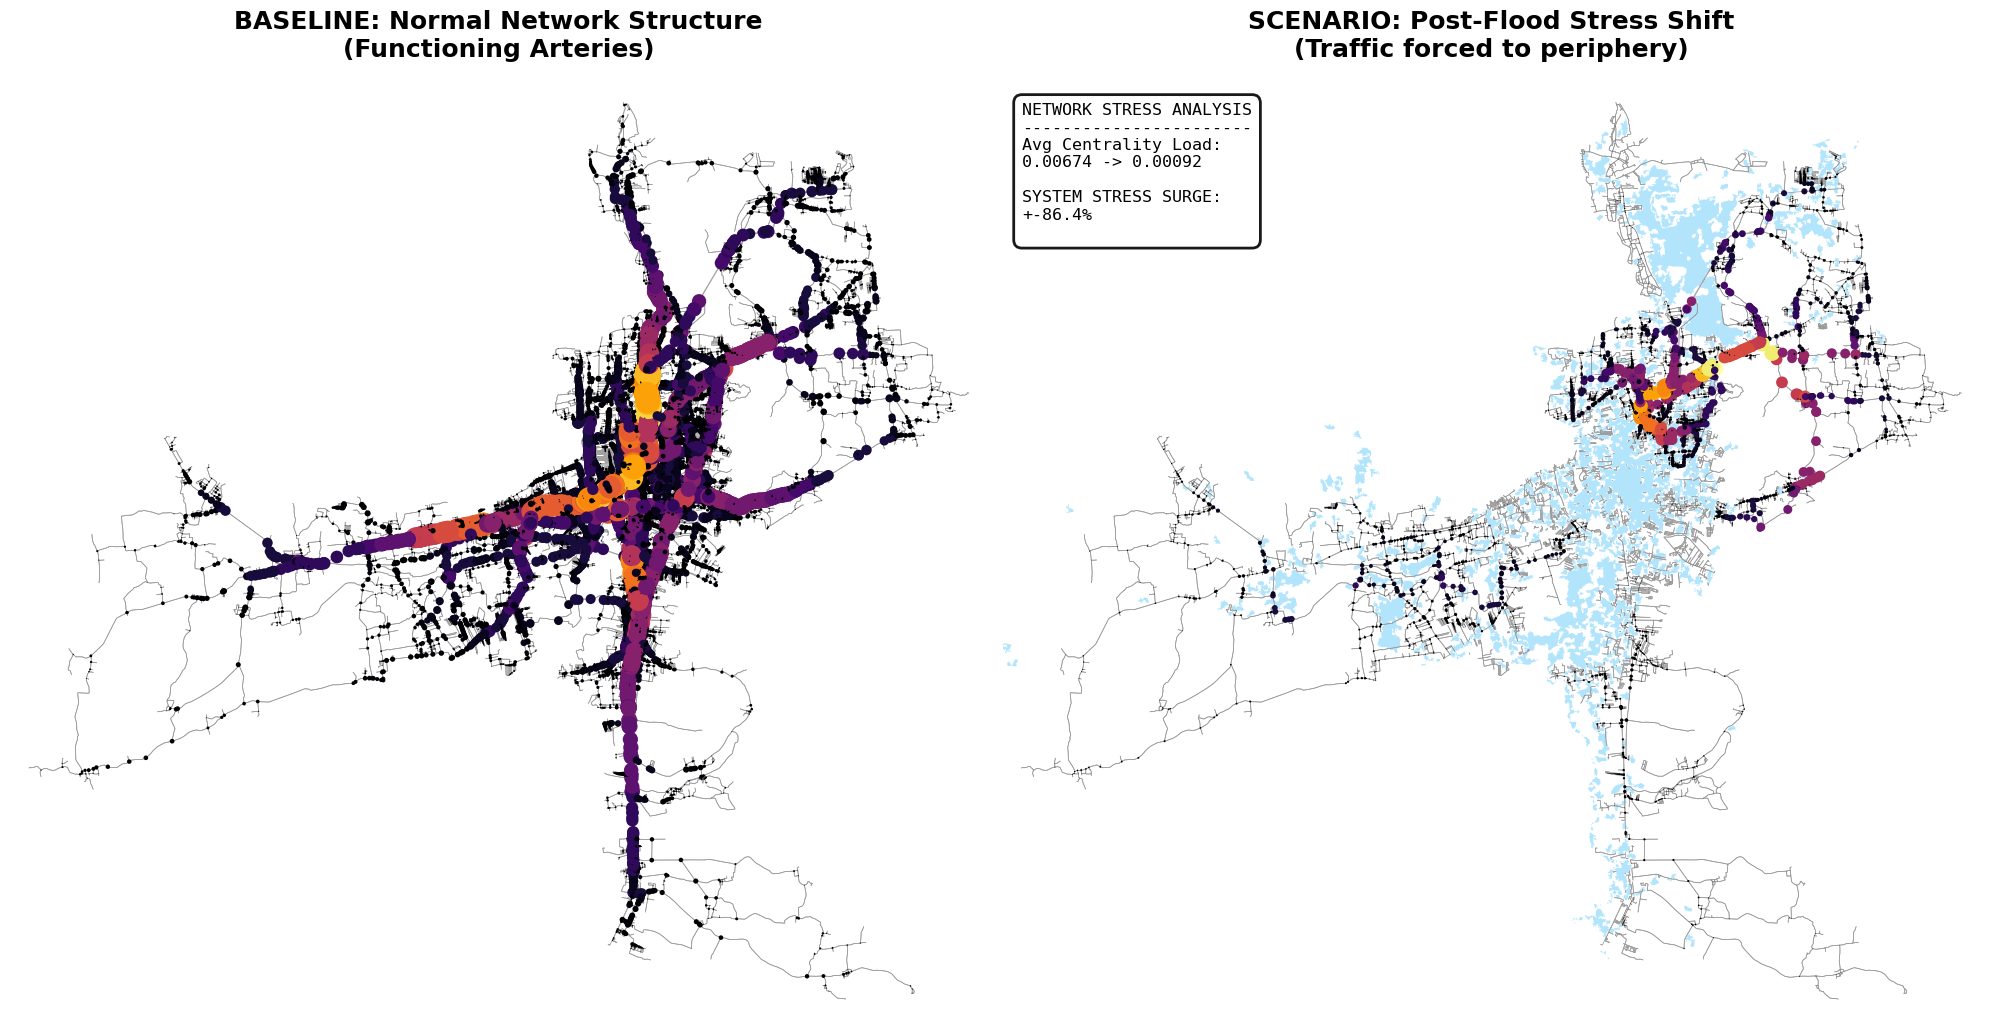

In [3]:
# Visualization
try:
    avg_base = np.mean(list(bc.values()))
    avg_flood = np.mean(list(bc_flood.values()))
    change_pct = ((avg_flood - avg_base) / avg_base) * 100
except:
    avg_base, avg_flood, change_pct = 0, 0, 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), facecolor='white')

cmap_style = 'inferno' 
road_color = '#999999' 

# Before (Baseline)
ns_base = [bc.get(node, 0) * 3000 for node in G_proj.nodes()] 
nc_base = ox.plot.get_node_colors_by_attr(G_proj, 'bc', cmap=cmap_style, num_bins=20)

ox.plot_graph(G_proj, ax=ax1, 
              node_color=nc_base, node_size=ns_base, node_zorder=2,
              edge_color=road_color, edge_linewidth=0.5, 
              bgcolor='white', 
              show=False, close=False)

ax1.set_title("BASELINE: Normal Network Structure\n(Functioning Arteries)", 
              color='black', fontsize=18, fontweight='bold', pad=20)

# After (Post-Flood)
ns_flood = [bc_flood.get(node, 0) * 3000 for node in G_flood.nodes()]
nc_flood = ox.plot.get_node_colors_by_attr(G_flood, 'bc_flood', cmap=cmap_style, num_bins=20)

ox.plot_graph(G_flood, ax=ax2, 
              node_color=nc_flood, node_size=ns_flood, node_zorder=2,
              edge_color=road_color, edge_linewidth=0.5, 
              bgcolor='white', 
              show=False, close=False)

# flood background
if 'flood_clean' in globals():

    flood_clean.plot(ax=ax2, color='#03A9F4', alpha=0.3, zorder=0)

ax2.set_title("SCENARIO: Post-Flood Stress Shift\n(Traffic forced to periphery)", 
              color='black', fontsize=18, fontweight='bold', pad=20)

stats_text = (
    f"NETWORK STRESS ANALYSIS\n"
    f"-----------------------\n"
    f"Avg Centrality Load:\n"
    f"{avg_base:.5f} -> {avg_flood:.5f}\n\n"
    f"SYSTEM STRESS SURGE:\n"
    f"+{change_pct:.1f}%\n"
)

ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, 
         fontsize=12, family='monospace', color='black', va='top', ha='left',

         bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.5', linewidth=2))

plt.tight_layout()
plt.show()

This structural displacement results in severe quantifiable and humanitarian impacts. The stress analysis indicates a system stress surge of +86.4%, indicating that peripheral roads originally designed for lower connectivity roles are now compelled to function as critical bridges well beyond their intended capacity. Such topological failure poses immediate risks to human safety and disaster response. The fragmentation of the grid severely impedes emergency logistics, making it difficult for ambulances and relief units to navigate between the disconnected urban "islands." Consequently, the exponential increase in travel costs translates directly into delayed response times and reduced accessibility, highlighting the network's acute vulnerability when life-saving operations are most needed.